# Lab IV: Linear Models - Question Set 1

### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## Property Data

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

In [34]:
property = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv ")
property.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 865.5 KB


Renaming Neighborhood to get rid of the space:

In [3]:
property = property.rename(columns = {"Neighbourhood ": "Neighbourhood"})
property.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


Let's take a quick look at the different values for each of the categorical variables:

In [4]:
print(property['Neighbourhood'].value_counts())
print("\n",property['Property Type'].value_counts())
print("\n",property['Room Type'].value_counts())

Neighbourhood
Manhattan        11763
Brooklyn          8487
Queens            1590
Bronx              217
Staten Island       96
Name: count, dtype: int64

 Property Type
Apartment          19656
House               1559
Loft                 591
Bed & Breakfast      136
Townhouse             83
Condominium           48
Other                 28
Dorm                  22
Boat                   6
Villa                  6
Camper/RV              6
Bungalow               3
Treehouse              3
Cabin                  2
Lighthouse             1
Chalet                 1
Castle                 1
Hut                    1
Name: count, dtype: int64

 Room Type
Entire home/apt    12883
Private room        8728
Shared room          542
Name: count, dtype: int64


##### 1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

Average Price and Score by Neighborhood:

In [5]:
property.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


First sorting it by price:

In [6]:
property.groupby("Neighbourhood")["Price"].mean().sort_values(ascending=False)

Neighbourhood
Manhattan        183.664286
Staten Island    146.166667
Brooklyn         127.747378
Queens            96.857233
Bronx             75.276498
Name: Price, dtype: float64

**Manhattan** is the most expensive on average.

Now making a kernel density plot of price grouped by neighbourhood. A kde plot is used to visualize the probability density function of a continuous variable (in this case price), which helps us understand the shape and spread of a distribution before modeling.

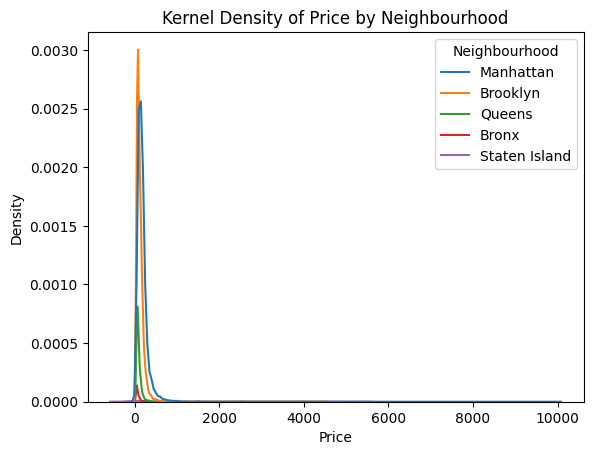

In [7]:
sns.kdeplot(property, x="Price", hue="Neighbourhood")
plt.title("Kernel Density of Price by Neighbourhood")
plt.show()

The plot looks heavily right skewed, but hopefully this can be fixed by taking the log of price:

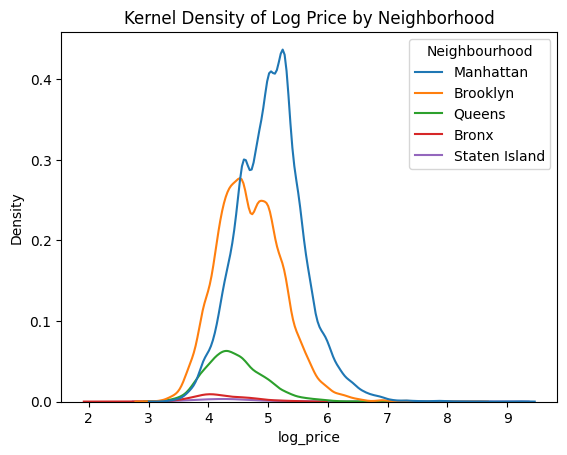

In [ ]:
# New Column in Data Frame
property["log_price"] = np.log(property["Price"])  # +1 to avoid log(0)

# kde plot
sns.kdeplot(property, x="log_price", hue="Neighbourhood")
plt.title("Kernel Density of Log Price by Neighborhood")
plt.show()

Looks better, and makes sense considering Manhattan has the tallest peak

##### 2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

First we will one-hot encode the "Neighbourhood" category:

In [9]:
neighbourhood = pd.get_dummies(property["Neighbourhood"])

Then we can create the linear regression model without an intercept:

In [10]:
# Defining our independent and dependent variables
X = neighbourhood
y = property["Price"]

# Model with no intercept
model = LinearRegression(fit_intercept=False).fit(X, y)

And examine the coefficients for each neighbourhood:

In [11]:
coefficients = pd.DataFrame({
    "Neighborhood": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by = "Coefficient", ascending = False))

    Neighborhood  Coefficient
2      Manhattan   183.664286
4  Staten Island   146.166667
1       Brooklyn   127.747378
3         Queens    96.857233
0          Bronx    75.276498


This table should look familiar, because the values of the coefficients are the exactly the same as the values for the mean price of properties in each neighbourhood. Just like before, we see Manhattan at the top, followed by Staten Island, Borrklyn, Queens, and the Bronx at the bottom.

This tells us that the coefficients of a regression of a continuous variable (price) on a categorical variable (neighbourhood) are simply just the group means of the dependent variable (price) for each category. This happens here because there is no intercept, so the coefficients of this simple linear regression model are the average price within each neighbourhood. 

##### 3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

Since now we are dealing with a model with an intercept, we need to make sure we avoid the dummy variable trap.

This occurs when the independent variables are multicollinear, which is the case here beacause the values in neighbourhood are highly correlated, meaning one value can be predicted from the others. 

To avoid the trap, we need to omit one column from neighbourhood (or any category when doing this) to ensure the model works; no information will be lost since we can still explain each column from the others.

For clarity and efficiency, let's just one-hot encode all the category columns, which includes neighbourhood, property type, and room type.

In [12]:
property = pd.get_dummies(
    property,
    columns=["Neighbourhood", "Property Type", "Room Type"],
    drop_first=True,  # drops first column
    prefix = ["Nb", "Property", "Room"]
)

In [13]:
property.head()

,Price,Review Scores Rating,log_price,Nb_Brooklyn,Nb_Manhattan,Nb_Queens,Nb_Staten Island,Property_Bed & Breakfast,Property_Boat,Property_Bungalow,...,Property_House,Property_Hut,Property_Lighthouse,Property_Loft,Property_Other,Property_Townhouse,Property_Treehouse,Property_Villa,Room_Private room,Room_Shared room
0,549,96.0,6.309918,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,149,100.0,5.010635,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,250,100.0,5.525453,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,90,94.0,4.510860,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,270,90.0,5.602119,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# regex ("regular expression") is a really good tool to define the independent variable because it
# selects all the columns that contain the expression "Nb_", which is exactly what encoding the columns
# gave us
X = property.filter(regex="Nb_")
y = property["Price"]

model = LinearRegression().fit(X, y)   # intercept included by default

Looking at the intercept:

In [15]:
print("Intercept:", model.intercept_)

Intercept: 75.27649769585331


That number is the just Bronx average price, which makes sense because that is the column that was dropped.

Now looking at the coefficients:

In [16]:
coefficients = pd.DataFrame({
    "Neighborhood": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

       Neighborhood  Coefficient
0       Nb_Brooklyn    52.470881
1      Nb_Manhattan   108.387789
2         Nb_Queens    21.580735
3  Nb_Staten Island    70.890169


Again, Bronx isn't listed because it was already dropped to avoid the dummy variable trap. 

These coefficients aren't the same as their average neighbourhood price, but instead they represent each neighbourhood's difference from the reference category of the Bronx:

This means that on average compared with the Bronx:
- Brooklyn property listings cost $52.47 more 
- Manhattan property listings cost $108.39 more
- Queens property listings cost $21.58 more
- Staten Island property listings cost $70.89 more


As a result, to get the coefficients from question 2 (the average price from each neighbourhood), we simply add the intercept to each coefficient:

In [17]:
averages = model.intercept_ + model.coef_

pd.DataFrame({
    "Neighborhood": X.columns,
    "Recovered Mean Price": averages
})

,Neighborhood,Recovered Mean Price
0,Nb_Brooklyn,127.747378
1,Nb_Manhattan,183.664286
2,Nb_Queens,96.857233
3,Nb_Staten Island,146.166667


And of course, the Bronx recovered mean price is again just the intercept mentioned previously, since that is what the other neighbourhood coefficients were based off of.

##### 4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

First we define our independent and dependent variables:

In [18]:
X = property.filter(regex="Review Scores Rating|Nb_")  # the | helps us search for more than one column
y = property["Price"]

Now we split into training and test data:

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=83)

Create and train the model:

In [20]:
model = LinearRegression().fit(X_train, y_train)

Use the model to make predictions on the test set:

In [21]:
y_pred = model.predict(X_test)

Finding $R^2$, which measures the proportion of variance in y that is explained by the model,
and RMSE, or root mean squared error, which measures the average magnitude of prediction erorrs (how far predictions are from actual values)

In [22]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.057716297303027186
RMSE: 134.330351737127


The $R^2$ is quite low, where the model only explains around 5.77% variation in property prices, meaning that neighbourhood and reveiw scores together aren't the best predictors of price, which is reasonable because there are likely plenty of other features that affect price.

Now let's find the coefficient on Review Scores Rating:

In [23]:
# Creating a coefficients dataframe like before
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

               Variable  Coefficient
0  Review Scores Rating     1.002097
1           Nb_Brooklyn    52.001466
2          Nb_Manhattan   108.512696
3             Nb_Queens    21.715548
4      Nb_Staten Island   102.528133


The coefficient on Review Scores Rating is 1.002, meaning that when neighbourhood is constant, a 1 point increase in review scores increases the property price by around 1.002, on average.

And finally, from the table, the most expensive kind of property you can rent is property in **Manhattan** since it has the highest coefficient.

##### 5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

Defining X and Y:

In [24]:
X = property.filter(regex="Review Scores Rating|Nb_|Property_")
y = property["Price"]

Split into training and testing data:

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=83)

Creating and fitting model, and making predictions:

In [26]:
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

Getting $R^2$ and RMSE:

In [27]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.06843909147623328
RMSE: 133.56385329862397


Our $R^2$ is a little higher and the RMSE is a little lower than the model from question 4 (that didn't include property type), meaning the model here performed ever so slightly better.

Now looking at the coefficients:

In [28]:
coefficients  = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending = False)

,Variable,Coefficient
2,Nb_Manhattan,1.200498e+02
4,Nb_Staten Island,9.455975e+01
7,Property_Bungalow,8.265986e+01
17,Property_Loft,6.721671e+01
19,Property_Townhouse,6.133114e+01
6,Property_Boat,6.012907e+01
1,Nb_Brooklyn,5.840454e+01
21,Property_Villa,5.047420e+01
20,Property_Treehouse,4.821526e+01
12,Property_Condominium,4.819488e+01


The coefficient for Review Scores Rating is still very close to 1, as it's a value of 1.0017 (holding all other variables constant, a increase of one review score leads to an average increase of 1.0017 in price).

The most expensive property type is **Bungalow** because it has the highest coefficient out of all the property values. Its coefficient of 82.66 means that holding everything else constant, a bungalow costs around $82.66 more per night than the baseline property type of apartment (that was dropped when one-hot encoding)

##### 6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

In question 4, the coefficient on Review Scores Rating is interpreted as a 1 point increase in rating leads to around a 1.0021 increase in property price while holding neighbourhood constant. However, in question 5, the coefficient measures ratings' affect on price by holding both neighbourhood and property type constant, and we see a slight change in the coefficient's value (1.0017)

When we add property type into the linear regression model, some of the variation in price that was previously attributed to ratings is now explained by property type, which is why the rating coefficient changes. This is because property and price might have some correlation. Therfore, making sure to ignore property when looking at rating's affect on price gives a more accurate isolated impact. In other words, the model in question 4 had the rating coefficient also partially capture the effect of property type, but the model in question 5 where we include property type as a variable in regression does a better job of isolating the true effect of ratings on price.

##### 7. We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [29]:
# First we need to define all the neighbourhood columns and all the property type columns (still dummy columns)
nb_cols = property.filter(like="Nb_")
prop_cols = property.filter(like="Property_")

# Creating an empty dataframe
combined = pd.DataFrame()

# Going through each column from above and creating a column in the new dataframe that includes both
# the neighbourhood and the property type. A cell is only True if both the neighbourhood and property type 
# are true for that property. 
for nb in nb_cols.columns:
    for prop in prop_cols.columns:
        combined[f"{nb}__{prop}"] = property[nb] * property[prop]

Defining our independent and dependent variables. Here, we need to add the Review scores rating to our combined dataframe from above in order to get a full dataframe that contains both the ratings and the combination property information.

In [30]:
# Using the cocat function to combined the rating column and the combined df
X = pd.concat(
    [property[["Review Scores Rating"]], combined],
    axis=1
)

y = property["Price"]

Now we create the model like usual:

In [31]:
# Data partitioning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=83)

# Model and predictions
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.029802145460621765
RMSE: 136.3055272320187


Coefficients:

In [32]:
coefficients  = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

coefficients.head()

,Variable,Coefficient
0,Review Scores Rating,9.113996e-01
1,Nb_Brooklyn__Property_Bed & Breakfast,-6.595973e+01
2,Nb_Brooklyn__Property_Boat,-5.652495e+01
3,Nb_Brooklyn__Property_Bungalow,-1.776357e-13
4,Nb_Brooklyn__Property_Cabin,5.506706e-14


Compared to question 5:
- The $R^2$ value decreased to around 0.03.
- The RMSE value increased slightly to 136.31
- The Review Scores Rating Coefficient decreased to around 0.91. 

The addition of interactions between neighbourhood and property type did not make the model better, likely because there was added complexity to the model, possibly leading to overfitting.

Also, the coefficients in this regression are not the sum of the coefficients for the respective neighbourhood/property type from question 5 since each interaction variable now has their own independent coefficient.

Finally, let's see the most expensive kind of property:

In [33]:
coefficients.sort_values(by="Coefficient", ascending=False).head()

,Variable,Coefficient
30,Nb_Manhattan__Property_Loft,182.126114
27,Nb_Manhattan__Property_House,164.528563
32,Nb_Manhattan__Property_Townhouse,163.060958
16,Nb_Brooklyn__Property_Treehouse,148.032043
31,Nb_Manhattan__Property_Other,121.098244


**Lofts in Manhattan** are the most expensive kind of property one can rent because it has the highest coefficient.